# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

#### **1.1.1**
Load the dataset

In [ ]:
# Load the data
df = pd.read_csv('data/Car_Price_data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [ ]:
df.head(10)

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
5,Audi A1,Sedans,15090,VAT deductible,63668.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,85.0,0,Metallic,Part/Full Leather,Automatic,1598.0,1135.0,front,3.5
6,Audi A1,Station wagon,16422,VAT deductible,62111.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,On-bo...",...,1.0,85.0,1,Metallic,Part/Full Leather,Automatic,1598.0,1195.0,front,3.7
7,Audi A1,Compact,14480,VAT deductible,14986.0,Used,Diesel,7.0,"Air conditioning,Armrest,Electrical side mirro...","CD player,MP3,Radio",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1180.0,front,3.7
8,Audi A1,Sedans,16700,VAT deductible,57000.0,Used,Diesel,7.0,"Air conditioning,Power windows",Radio,...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1275.0,front,3.7
9,Audi A1,Sedans,17990,VAT deductible,16103.0,Used,Benzine,7.0,"Air conditioning,Armrest,Automatic climate con...",Radio,...,1.0,70.0,0,Metallic,Cloth,Automatic,999.0,1135.0,front,4.2


## **2 Analysis and Feature Engineering**

### **2.1 Preliminary Analysis and Frequency Distributions**

#### **2.1.1**Check and fix missing values.

In [ ]:
# Find the proportion of missing values in each column and handle if found
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing_values, 'missing_percentage': missing_percentage})

print("Missing values before update:\n",missing_df)

Missing values before update:
                      missing_count  missing_percentage
make_model                       0                 0.0
body_type                        0                 0.0
price                            0                 0.0
vat                              0                 0.0
km                               0                 0.0
Type                             0                 0.0
Fuel                             0                 0.0
Gears                            0                 0.0
Comfort_Convenience              0                 0.0
Entertainment_Media              0                 0.0
Extras                           0                 0.0
Safety_Security                  0                 0.0
age                              0                 0.0
Previous_Owners                  0                 0.0
hp_kW                            0                 0.0
Inspection_new                   0                 0.0
Paint_Type                       0

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2**Identify numerical predictors and plot their frequency distributions.

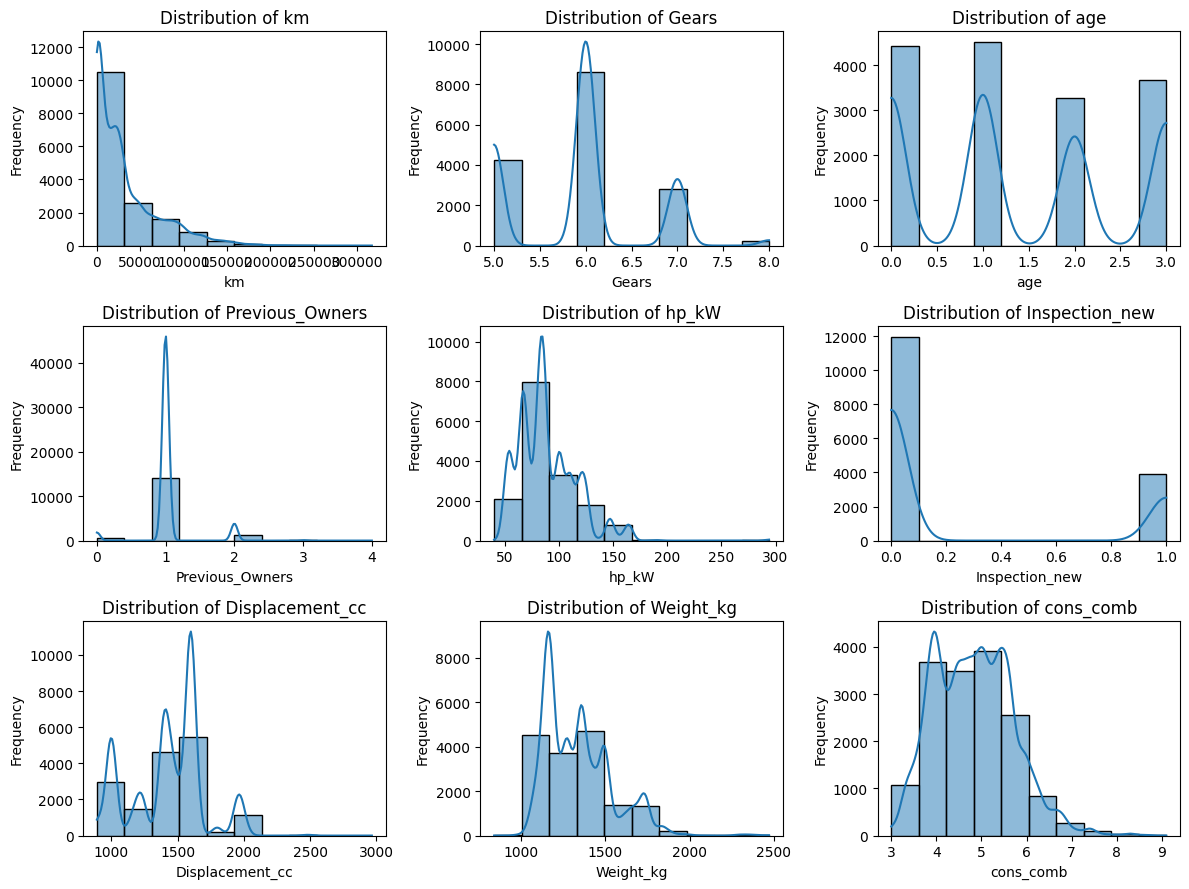

In [ ]:
# Identify numerical features and plot histograms
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'price' as it's the target variable and will be handled separately
if 'price' in numerical_features:
    numerical_features.remove('price')

# Plotting histograms for numerical features
plt.figure(figsize=(12, 9))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=10)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### **2.1.3**Identify categorical predictors and plot their frequency distributions.

Skipping plotting for 'Comfort_Convenience' due to too many unique values (6196).
Skipping plotting for 'Entertainment_Media' due to too many unique values (346).
Skipping plotting for 'Extras' due to too many unique values (659).
Skipping plotting for 'Safety_Security' due to too many unique values (4442).


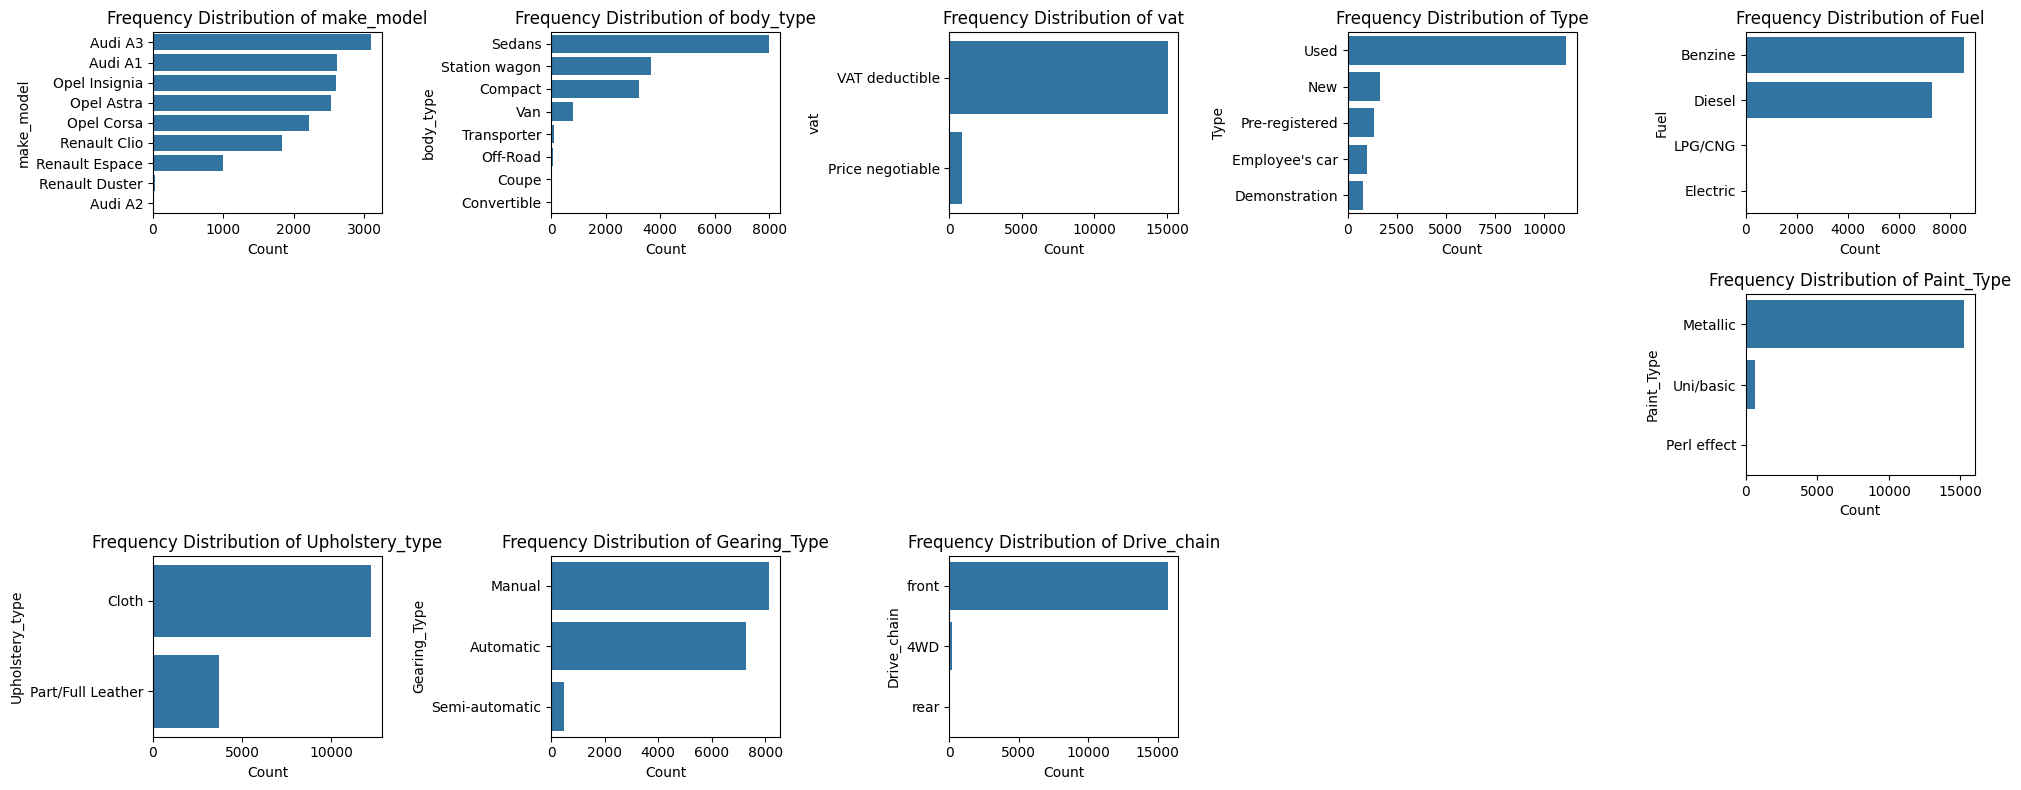

In [ ]:
# Identify categorical columns and check their frequency distributions
# Identify categorical columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Plotting frequency distributions for categorical features
plt.figure(figsize=(20, 8))
for i, col in enumerate(categorical_features):
    if df[col].nunique() < 50: # Only plot if number of unique values is reasonable
        plt.subplot(3, 5, i + 1) # Adjust subplot grid as needed
        sns.countplot(y=df[col], order = df[col].value_counts().index)
        plt.title(f'Frequency Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
    else:
        print(f"Skipping plotting for '{col}' due to too many unique values ({df[col].nunique()}).")
plt.tight_layout()
plt.show()

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

In [ ]:
# Count number of unique values in coloumns["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"].
unique_values = df[["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]].nunique()
print(unique_values)

Comfort_Convenience    6196
Entertainment_Media     346
Extras                  659
Safety_Security        4442
dtype: int64


#### **2.1.4**Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [ ]:
# Fix columns as needed
# Function that list all categories/values of a provided column sorted by frequency ASC:
def list_categories_by_frequency(dataframe, column_name):
    if column_name not in dataframe.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return
    if dataframe[column_name].dtype == 'object' or pd.api.types.is_categorical_dtype(dataframe[column_name]):
        print(f"Categories in '{column_name}' (sorted by frequency ascending):\n")
        # Get value counts, sort by index (category) then by value (frequency) ascending
        frequency_distribution = dataframe[column_name].value_counts().sort_values(ascending=True)
        print(frequency_distribution)
    else:
        print(f"Column '{column_name}' is not a categorical type. Its dtype is {dataframe[column_name].dtype}.")

# Function that fix low frequency values:
def replace_low_frequency_categories(df, column_name, categories_to_check, imputing_value):
    # Identify categories to replace that actually exist in the column
    categories_to_replace = [
        cat for cat in categories_to_check
        if cat in df[column_name].unique()
    ]

    if categories_to_replace:
        print(f"Replacing categories in '{column_name}' with '{imputing_value}': {categories_to_replace}")
        df[column_name] = df[column_name].replace(categories_to_replace, imputing_value)
    else:
        print(f"No specified categories in '{column_name}' were found for replacement.")

    # Display updated categories
    list_categories_by_frequency(df, column_name)

    return df


In [ ]:
# Type
list_categories_by_frequency(df, 'Type')

# Let's group Pre-registered into New, while the rest will be grouped into Used, keeping onto two main Types:
replace_low_frequency_categories(df, 'Type', ['Pre-registered'], 'New')

replace_low_frequency_categories (df, 'Type', ['Demonstration',"Employee's car"], 'Used')

Categories in 'Type' (sorted by frequency ascending):

Type
Demonstration       796
Employee's car     1011
Pre-registered     1364
New                1649
Used              11095
Name: count, dtype: int64
Replacing categories in 'Type' with 'New': ['Pre-registered']
Categories in 'Type' (sorted by frequency ascending):

Type
Demonstration       796
Employee's car     1011
New                3013
Used              11095
Name: count, dtype: int64
Replacing categories in 'Type' with 'Used': ['Demonstration', "Employee's car"]
Categories in 'Type' (sorted by frequency ascending):

Type
New      3013
Used    12902
Name: count, dtype: int64


,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.000000,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.000000,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15911,Renault Espace,Van,39885,VAT deductible,9900.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,R...",...,1.0,165.0,0,Metallic,Cloth,Automatic,1798.0,1708.0,front,7.4
15912,Renault Espace,Van,39875,VAT deductible,15.000000,New,Diesel,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,146.0,1,Metallic,Part/Full Leather,Automatic,1997.0,1734.0,front,5.3
15913,Renault Espace,Van,39700,VAT deductible,10.000000,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3


In [ ]:
# make_model
list_categories_by_frequency(df, 'make_model')

# Replace "Audi A2" and "Renault Duster" by "Others"
replace_low_frequency_categories(df, 'make_model', ['Audi A2','Renault Duster'], 'Others')

Categories in 'make_model' (sorted by frequency ascending):

make_model
Audi A2              1
Renault Duster      34
Renault Espace     991
Renault Clio      1839
Opel Corsa        2216
Opel Astra        2525
Opel Insignia     2598
Audi A1           2614
Audi A3           3097
Name: count, dtype: int64
Replacing categories in 'make_model' with 'Others': ['Audi A2', 'Renault Duster']
Categories in 'make_model' (sorted by frequency ascending):

make_model
Others              35
Renault Espace     991
Renault Clio      1839
Opel Corsa        2216
Opel Astra        2525
Opel Insignia     2598
Audi A1           2614
Audi A3           3097
Name: count, dtype: int64


,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.000000,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.000000,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15911,Renault Espace,Van,39885,VAT deductible,9900.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,R...",...,1.0,165.0,0,Metallic,Cloth,Automatic,1798.0,1708.0,front,7.4
15912,Renault Espace,Van,39875,VAT deductible,15.000000,New,Diesel,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,146.0,1,Metallic,Part/Full Leather,Automatic,1997.0,1734.0,front,5.3
15913,Renault Espace,Van,39700,VAT deductible,10.000000,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3


In [ ]:
# body_type
list_categories_by_frequency(df, 'body_type')

# The smaller frequency categories will all be under new category called "Others"
replace_low_frequency_categories(df, 'body_type', ['Convertible','Coupe','Off-Road','Transporter'], 'Others')

Categories in 'body_type' (sorted by frequency ascending):

body_type
Convertible         8
Coupe              25
Off-Road           56
Transporter        88
Van               817
Compact          3240
Station wagon    3677
Sedans           8004
Name: count, dtype: int64
Replacing categories in 'body_type' with 'Others': ['Convertible', 'Coupe', 'Off-Road', 'Transporter']
Categories in 'body_type' (sorted by frequency ascending):

body_type
Others            177
Van               817
Compact          3240
Station wagon    3677
Sedans           8004
Name: count, dtype: int64


,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.000000,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.000000,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15911,Renault Espace,Van,39885,VAT deductible,9900.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,R...",...,1.0,165.0,0,Metallic,Cloth,Automatic,1798.0,1708.0,front,7.4
15912,Renault Espace,Van,39875,VAT deductible,15.000000,New,Diesel,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,146.0,1,Metallic,Part/Full Leather,Automatic,1997.0,1734.0,front,5.3
15913,Renault Espace,Van,39700,VAT deductible,10.000000,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3


In [ ]:
# vat
list_categories_by_frequency(df, 'vat')

# Keep vat as is

Categories in 'vat' (sorted by frequency ascending):

vat
Price negotiable      871
VAT deductible      15044
Name: count, dtype: int64


In [ ]:
# Fuel
list_categories_by_frequency(df, 'Fuel')

# Group Electric and LPG into Others
replace_low_frequency_categories(df, 'Fuel', ['Electric','LPG/CNG'], 'Others')

Categories in 'Fuel' (sorted by frequency ascending):

Fuel
Electric       5
LPG/CNG       64
Diesel      7298
Benzine     8548
Name: count, dtype: int64
Replacing categories in 'Fuel' with 'Others': ['Electric', 'LPG/CNG']
Categories in 'Fuel' (sorted by frequency ascending):

Fuel
Others       69
Diesel     7298
Benzine    8548
Name: count, dtype: int64


,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.000000,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.000000,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15911,Renault Espace,Van,39885,VAT deductible,9900.000000,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,R...",...,1.0,165.0,0,Metallic,Cloth,Automatic,1798.0,1708.0,front,7.4
15912,Renault Espace,Van,39875,VAT deductible,15.000000,New,Diesel,6.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,146.0,1,Metallic,Part/Full Leather,Automatic,1997.0,1734.0,front,5.3
15913,Renault Espace,Van,39700,VAT deductible,10.000000,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3


In [ ]:
# Paint_Type
list_categories_by_frequency(df, 'Paint_Type')

# Keep as is

Categories in 'Paint_Type' (sorted by frequency ascending):

Paint_Type
Perl effect       32
Uni/basic        637
Metallic       15246
Name: count, dtype: int64


In [ ]:
# Upholstery_type
list_categories_by_frequency(df, 'Upholstery_type')

# Keep as is

Categories in 'Upholstery_type' (sorted by frequency ascending):

Upholstery_type
Part/Full Leather     3681
Cloth                12234
Name: count, dtype: int64


In [ ]:
# Gearing_type
list_categories_by_frequency(df, 'Gearing_Type')

# Keep as is

Categories in 'Gearing_Type' (sorted by frequency ascending):

Gearing_Type
Semi-automatic     469
Automatic         7297
Manual            8149
Name: count, dtype: int64


In [ ]:
# Drive_chain
list_categories_by_frequency(df, 'Drive_chain')

#Keep as is

Categories in 'Drive_chain' (sorted by frequency ascending):

Drive_chain
rear         4
4WD        204
front    15707
Name: count, dtype: int64


#### **2.1.5**Identify target variable and plot the frequency distributions. Apply necessary transformations.

Text(0.5, 0, 'price')

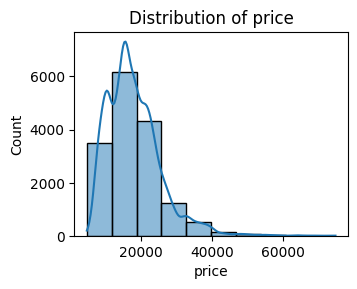

In [ ]:
# Plot histograms for target feature
plt.figure(figsize=(12, 9))
plt.subplot(3, 3, 1)
sns.histplot(df['price'], kde=True, bins=10)
plt.title(f'Distribution of price')
plt.xlabel('price')

**The target variable seems to be skewed. Perform suitable transformation on the target.**

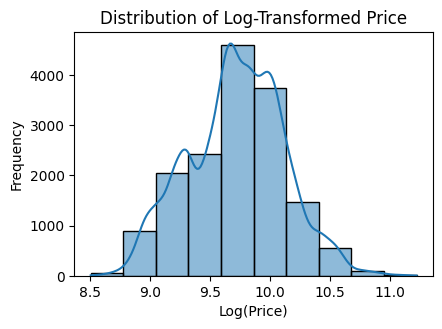

In [ ]:
# Transform the target feature (price) using log1p to handle skewness
df['price_log'] = np.log1p(df['price'])

# Plot the distribution of the transformed price
plt.figure(figsize=(12, 9))
plt.subplot(3, 3, 1)
sns.histplot(df['price_log'], kde=True, bins=10)
plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **2.2 Correlation analysis**

#### **2.2.1**Plot the correlation map between features and target variable.

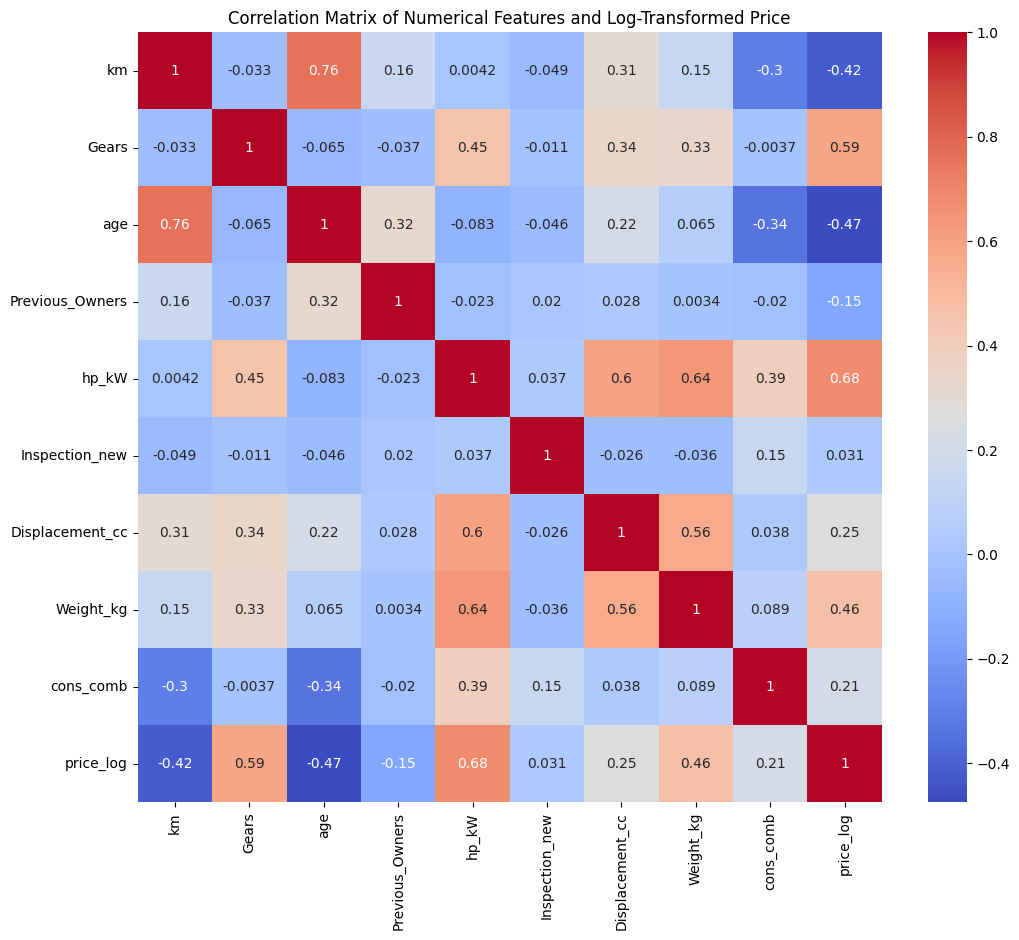

In [ ]:
# Visualise correlation
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_features + ['price_log']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features and Log-Transformed Price')
plt.show()

#### **2.2.2**Analyse correlation between categorical features and target variable.

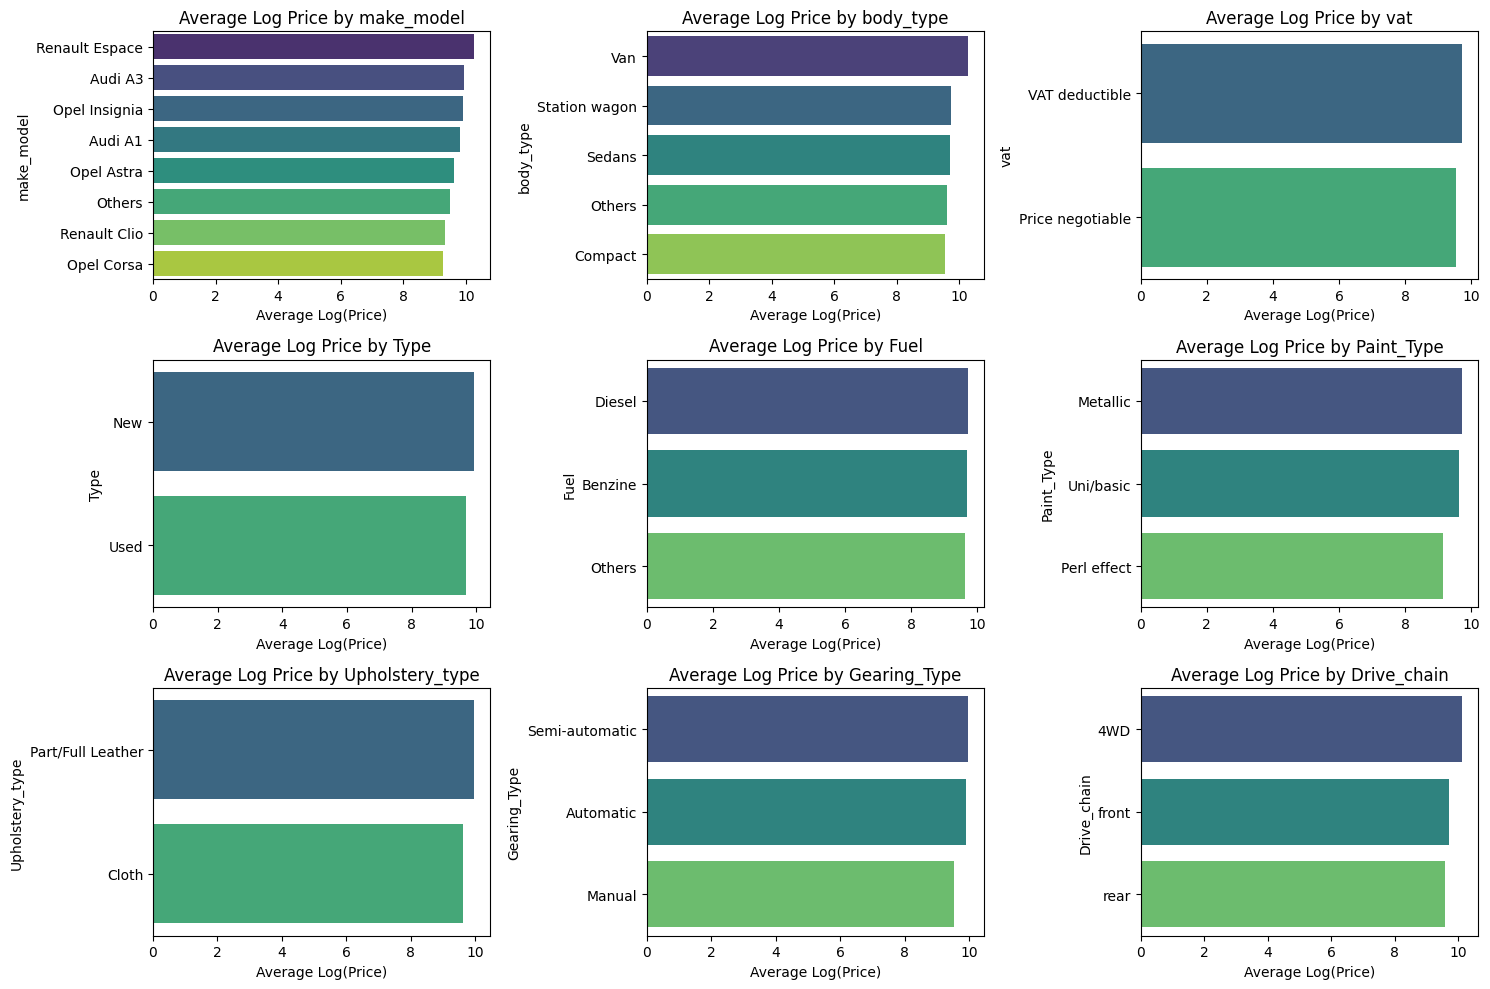

In [ ]:
# Comparing average values of target for different categories

# Exclude columns that were previously identified as having too many unique values
excluded_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

# Filter the categorical features list
plot_categorical_features = [col for col in categorical_features if col not in excluded_cols]

plt.figure(figsize=(15, 10))
for i, col in enumerate(plot_categorical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    avg_price_log = df.groupby(col)['price_log'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_price_log.values, y=avg_price_log.index, palette='viridis')
    plt.title(f'Average Log Price by {col}')
    plt.xlabel('Average Log(Price)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **2.3 Outlier analysis**

#### **2.3.1**Identify potential outliers in the data.

In [ ]:
# Identify potential outliers in each numerical column using the IQR method

# Combine numerical_features and price_log into a list of columns to check for outliers
columns_to_check = numerical_features + ['price_log']

for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    if not outliers.empty:
        print(f"\nColumn '{col}':")
        print(f"  - Number of outliers: {len(outliers)}")
        print(f"  - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  - Min Outlier Value: {outliers.min():.2f}, Max Outlier Value: {outliers.max():.2f}")
    else:
        print(f"\nColumn '{col}': No significant outliers detected.")


Column 'km':
  - Number of outliers: 689
  - Lower Bound: -65548.75, Upper Bound: 114369.25
  - Min Outlier Value: 114550.00, Max Outlier Value: 317000.00

Column 'Gears':
  - Number of outliers: 225
  - Lower Bound: 3.50, Upper Bound: 7.50
  - Min Outlier Value: 8.00, Max Outlier Value: 8.00

Column 'age': No significant outliers detected.

Column 'Previous_Owners':
  - Number of outliers: 1757
  - Lower Bound: 1.00, Upper Bound: 1.00
  - Min Outlier Value: 0.00, Max Outlier Value: 4.00

Column 'hp_kW':
  - Number of outliers: 361
  - Lower Bound: 10.50, Upper Bound: 158.50
  - Min Outlier Value: 162.00, Max Outlier Value: 294.00

Column 'Inspection_new':
  - Number of outliers: 3932
  - Lower Bound: 0.00, Upper Bound: 0.00
  - Min Outlier Value: 1.00, Max Outlier Value: 1.00

Column 'Displacement_cc':
  - Number of outliers: 21
  - Lower Bound: 675.50, Upper Bound: 2151.50
  - Min Outlier Value: 2480.00, Max Outlier Value: 2967.00

Column 'Weight_kg':
  - Number of outliers: 87
  - 

#### **2.3.2**Handle the outliers suitably.

In [ ]:
# Handle outliers using Winsorization (capping at 1st and 99th percentiles)

# Columns to apply Winsorization
winsorize_cols = ['km', 'hp_kW', 'cons_comb']

for col in winsorize_cols:
    # Calculate 1st and 99th percentiles
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)

    # Apply capping
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Column '{col}' winsorized between {lower_bound:.2f} and {upper_bound:.2f}")

print("\nOutliers handled using Winsorization for selected columns.")

# Re-check outliers for the winsorized columns to confirm
print("\nOutlier check after Winsorization:")
for col in winsorize_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound_iqr = Q1 - 1.5 * IQR
    upper_bound_iqr = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound_iqr) | (df[col] > upper_bound_iqr)][col]

    if not outliers.empty:
        print(f"\nColumn '{col}': {len(outliers)} potential outliers remaining after winsorization (using IQR method).")
    else:
        print(f"\nColumn '{col}': No significant outliers detected after winsorization (using IQR method).")

Column 'km' winsorized between 1.00 and 154987.40
Column 'hp_kW' winsorized between 51.00 and 165.00
Column 'cons_comb' winsorized between 3.30 and 7.10

Outliers handled using Winsorization for selected columns.

Outlier check after Winsorization:

Column 'km': 689 potential outliers remaining after winsorization (using IQR method).

Column 'hp_kW': 361 potential outliers remaining after winsorization (using IQR method).

Column 'cons_comb': No significant outliers detected after winsorization (using IQR method).


In [ ]:
# Continue handling outliers using Winsorization (capping at 5th and 95th percentiles)

# Remaining columns to apply Winsorization
winsorize_cols = ['km', 'hp_kW']

for col in winsorize_cols:
    # Calculate 1st and 99th percentiles
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)

    # Apply capping
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Column '{col}' winsorized between {lower_bound:.2f} and {upper_bound:.2f}")

print("\nOutliers handled using Winsorization for selected columns.")

# Re-check outliers for the winsorized columns to confirm
print("\nOutlier check after Winsorization:")
for col in winsorize_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound_iqr = Q1 - 1.5 * IQR
    upper_bound_iqr = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound_iqr) | (df[col] > upper_bound_iqr)][col]

    if not outliers.empty:
        print(f"\nColumn '{col}': {len(outliers)} potential outliers remaining after winsorization (using IQR method).")
    else:
        print(f"\nColumn '{col}': No significant outliers detected after winsorization (using IQR method).")

Column 'km' winsorized between 10.00 and 109930.00
Column 'hp_kW' winsorized between 54.00 and 146.00

Outliers handled using Winsorization for selected columns.

Outlier check after Winsorization:

Column 'km': No significant outliers detected after winsorization (using IQR method).

Column 'hp_kW': No significant outliers detected after winsorization (using IQR method).


### **2.4 Feature Engineering**

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [ ]:
# Fix/create columns as needed

# Drop price column that is replaced by price_log
df.drop(columns=['price'], inplace=True)

#### **2.4.2**Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [ ]:
# Check unique values in each feature spec column
feature_spec_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

for col in feature_spec_cols:
    all_individual_features = []
    for entry in df[col]:
        if pd.notna(entry) and isinstance(entry, str):
            all_individual_features.extend([f.strip() for f in entry.split(',')])

    feature_counts = {}
    for feature in all_individual_features:
        feature_counts[feature] = feature_counts.get(feature, 0) + 1

    total_cars = len(df)
    print(f"\nFrequency Distribution for individual features in '{col}':")
    # Sort by count in ascending order, also display the proportion
    for feature, count in sorted(feature_counts.items(), key=lambda item: item[1]):
        proportion = count / total_cars
        print(f"  '{feature}': {count} (Proportion: {proportion:.4f})")


Frequency Distribution for individual features in 'Comfort_Convenience':
  'Electric Starter': 1 (Proportion: 0.0001)
  'Windshield': 12 (Proportion: 0.0008)
  'Wind deflector': 41 (Proportion: 0.0026)
  'Leather seats': 48 (Proportion: 0.0030)
  'Air suspension': 66 (Proportion: 0.0041)
  'Auxiliary heating': 266 (Proportion: 0.0167)
  'Massage seats': 360 (Proportion: 0.0226)
  'Sunroof': 372 (Proportion: 0.0234)
  'Heads-up display': 609 (Proportion: 0.0383)
  'Panorama roof': 618 (Proportion: 0.0388)
  'Parking assist system self-steering': 771 (Proportion: 0.0484)
  'Seat ventilation': 838 (Proportion: 0.0527)
  'Electrically heated windshield': 944 (Proportion: 0.0593)
  'Electric tailgate': 1113 (Proportion: 0.0699)
  'Tinted windows': 1448 (Proportion: 0.0910)
  'Electrically adjustable seats': 2077 (Proportion: 0.1305)
  'Split rear seats': 2391 (Proportion: 0.1502)
  'Keyless central door lock': 2794 (Proportion: 0.1756)
  'Heated steering wheel': 3209 (Proportion: 0.2016)
 

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [ ]:
# Define thresholds for common and rare features
common_threshold = 0.90  # Features present in more than 90% of cars
rare_threshold = 0.10    # Features present in less than 10% of cars

# Drop features from df
filtered_features = {}
for col in feature_spec_cols:
    all_individual_features = []
    for entry in df[col]:
        if pd.notna(entry) and isinstance(entry, str):
            all_individual_features.extend([f.strip() for f in entry.split(',')])
    feature_counts = {}
    for feature in all_individual_features:
        feature_counts[feature] = feature_counts.get(feature, 0) + 1

    total_cars = len(df)
    current_col_filtered_features = []
    print(f"\nAnalyzing individual features for '{col}':")
    for feature, count in feature_counts.items():
        proportion = count / total_cars
        if proportion > common_threshold:
            print(f"  '{feature}': {count} ({proportion:.2f}) - Too common, will be dropped.")
        elif proportion < rare_threshold:
            print(f"  '{feature}': {count} ({proportion:.2f}) - Too rare, will be dropped.")
        else:
            current_col_filtered_features.append(feature)
            print(f"  '{feature}': {count} ({proportion:.2f}) - Kept.")
    filtered_features[col] = current_col_filtered_features



Analyzing individual features for 'Comfort_Convenience':
  'Air conditioning': 15095 (0.95) - Too common, will be dropped.
  'Armrest': 7600 (0.48) - Kept.
  'Automatic climate control': 9197 (0.58) - Kept.
  'Cruise control': 11622 (0.73) - Kept.
  'Electrical side mirrors': 12488 (0.78) - Kept.
  'Hill Holder': 7335 (0.46) - Kept.
  'Leather steering wheel': 9735 (0.61) - Kept.
  'Light sensor': 8034 (0.50) - Kept.
  'Multi-function steering wheel': 11744 (0.74) - Kept.
  'Navigation system': 8538 (0.54) - Kept.
  'Park Distance Control': 10655 (0.67) - Kept.
  'Parking assist system sensors rear': 10086 (0.63) - Kept.
  'Power windows': 14756 (0.93) - Too common, will be dropped.
  'Rain sensor': 9062 (0.57) - Kept.
  'Seat heating': 7420 (0.47) - Kept.
  'Start-stop system': 9455 (0.59) - Kept.
  'Lumbar support': 3478 (0.22) - Kept.
  'Tinted windows': 1448 (0.09) - Too rare, will be dropped.
  'Parking assist system sensors front': 6103 (0.38) - Kept.
  'Air suspension': 66 (0.0

#### **2.4.3**Perform feature encoding.

In [ ]:
# Encode features
# Create new binary features for the filtered individual features (one-hot encoding)
for col, features_to_keep in filtered_features.items():
    for feature in features_to_keep:
        # Create a new column with a descriptive name, e.g., 'has_Air conditioning'
        df[f'has_{feature.replace(" ", "_")}'] = df[col].apply(lambda x: 1 if feature in x else 0)

# Drop the original feature specification columns
df.drop(columns=feature_spec_cols, inplace=True)

print(f"Original columns {feature_spec_cols} dropped. New binary features created.")
print(f"New DataFrame shape: {df.shape}")

df.head()

Original columns ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security'] dropped. New binary features created.
New DataFrame shape: (15915, 75)


,make_model,body_type,vat,km,Type,Fuel,Gears,age,Previous_Owners,hp_kW,...,has_Xenon_headlights,has_Central_door_lock_with_remote_control,has_Head_airbag,has_Alarm_system,has_LED_Headlights,has_Adaptive_headlights,has_LED_Daytime_Running_Lights,has_Emergency_brake_assistant,has_Traffic_sign_recognition,has_Lane_departure_warning_system
0,Audi A1,Sedans,VAT deductible,56013.0,Used,Diesel,7.0,3.0,2.0,66.0,...,1,0,0,0,0,0,0,0,0,0
1,Audi A1,Sedans,Price negotiable,80000.0,Used,Benzine,7.0,2.0,1.0,141.0,...,1,1,1,0,0,0,0,0,0,0
2,Audi A1,Sedans,VAT deductible,83450.0,Used,Diesel,7.0,3.0,1.0,85.0,...,0,0,0,0,0,0,0,0,0,0
3,Audi A1,Sedans,VAT deductible,73000.0,Used,Diesel,6.0,3.0,1.0,66.0,...,0,1,1,1,0,0,0,0,0,0
4,Audi A1,Sedans,VAT deductible,16200.0,Used,Diesel,7.0,3.0,1.0,66.0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
# Encode the remaining categorical features
df = pd.get_dummies(df, columns=plot_categorical_features, drop_first=True)

print(f"DataFrame shape after one-hot encoding: {df.shape}")

df.info()

KeyError: "None of [Index(['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type',\n       'Upholstery_type', 'Gearing_Type', 'Drive_chain'],\n      dtype='object')] are in the [columns]"

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 88 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   km                                         15915 non-null  float64
 1   Gears                                      15915 non-null  float64
 2   age                                        15915 non-null  float64
 3   Previous_Owners                            15915 non-null  float64
 4   hp_kW                                      15915 non-null  float64
 5   Inspection_new                             15915 non-null  int64  
 6   Displacement_cc                            15915 non-null  float64
 7   Weight_kg                                  15915 non-null  float64
 8   cons_comb                                  15915 non-null  float64
 9   price_log                                  15915 non-null  float64
 10  has_Armrest           

#### **2.4.4**Split the data into training and testing sets.

In [ ]:
# Split data
# Define features (X) and target (y)
X = df.drop(columns=['price_log'])
y = df['price_log']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (12732, 87)
X_test shape: (3183, 87)
y_train shape: (12732,)
y_test shape: (3183,)


#### **2.4.5**Scale the features.

In [ ]:
# Scale features
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, preserving column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (12732, 87)
X_test_scaled shape: (3183, 87)


## **3 Linear Regression Models**

### **3.1 Baseline Linear Regression Model**

#### **3.1.1**Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [ ]:
# Initialise and train model
car_price_prediction = LinearRegression()
car_price_prediction.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Evaluate the model's performance
# Make predictions on the scaled test data
y_pred = car_price_prediction.predict(X_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.0804
Mean Squared Error (MSE): 0.0116
Root Mean Squared Error (RMSE): 0.1077
R-squared (R2): 0.9275


#### **3.1.2**Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

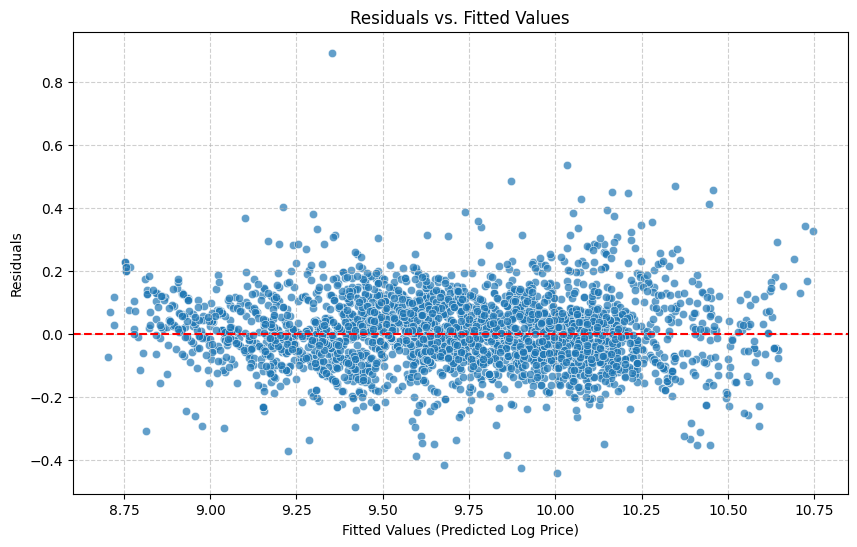

In [ ]:
# Linearity check: Plot residuals vs fitted values
residuals = y_test - y_pred
fitted_values = y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values (Predicted Log Price)')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Check normality in residual distribution

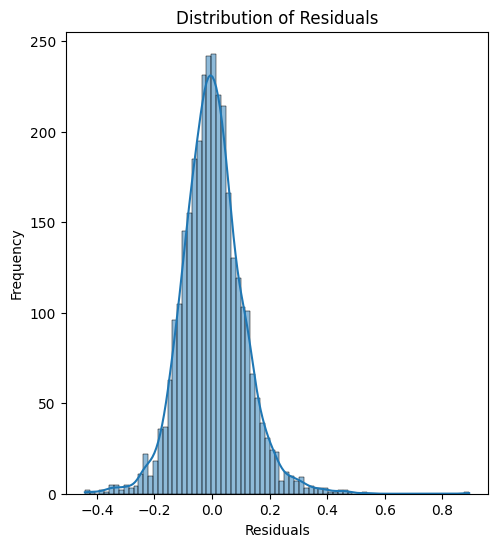

In [ ]:
# Check the normality of residuals by plotting their distribution
plt.figure(figsize=(12, 6))

# Histogram of residuals
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [ ]:
# Check for multicollinearity

### **3.2 Ridge Regression Implementation**

#### **3.2.1**Define a list of random alpha values

In [ ]:
# List of alphas to tune for Ridge regularisation
alphas_ridge = np.logspace(-4, 2, 100)

#### **3.2.2**Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Applying Ridge regression
ridge = Ridge()
parameters = {'alpha': alphas_ridge}

car_price_prediction_ridge = GridSearchCV(ridge, parameters, scoring='neg_mean_absolute_error', cv=5)
car_price_prediction_ridge.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226722e-03, 1.23284674e-03, 1....
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
             scoring='neg_mean_absolute_error')

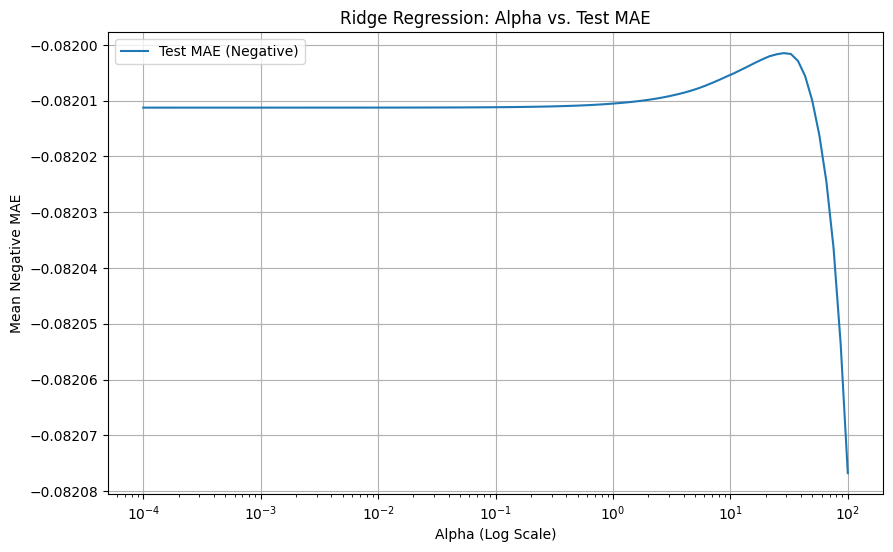

In [ ]:
# Plot train and test scores against alpha

# Convert GridSearchCV results to a DataFrame for easier plotting
car_price_prediction_ridge_df = pd.DataFrame(car_price_prediction_ridge.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(car_price_prediction_ridge_df['param_alpha'], car_price_prediction_ridge_df['mean_test_score'], label='Test MAE (Negative)')
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Negative MAE')
plt.title('Ridge Regression: Alpha vs. Test MAE')
plt.legend()
plt.grid(True)
plt.show()

Find the best alpha value.

In [ ]:
# Best alpha value
best_alpha_ridge = car_price_prediction_ridge.best_params_['alpha']
print(f"Best alpha for Ridge: {best_alpha_ridge:.4f}")

# Best score (negative MAE)
best_score_ridge = car_price_prediction_ridge.best_score_
print(f"Best score (negative MAE) for Ridge: {best_score_ridge:.4f}")

Best alpha for Ridge: 28.4804
Best score (negative MAE) for Ridge: -0.0820


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3**Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# Take a smaller range of alpha to test
alpha_min = max(0.0001, best_alpha_ridge * 0.5) # Ensure alpha is not too small or negative
alpha_max = best_alpha_ridge * 1.5
alphas_ridge_fine_tune = np.linspace(alpha_min, alpha_max, 100)

In [ ]:
# Applying Ridge regression
ridge_fine_tune = Ridge()
parameters_fine_tune = {'alpha': alphas_ridge_fine_tune}

car_price_prediction_ridge_fine_tune = GridSearchCV(ridge_fine_tune, parameters_fine_tune, scoring='neg_mean_absolute_error', cv=5)
car_price_prediction_ridge_fine_tune.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([14.24017934, 14.52785973, 14.81554012, 15.10322051, 15.39090091,
       15.6785813 , 15.96626169, 16.25394208, 16.54162247, 16.82930286,
       17.11698325, 17.40466364, 17.69234403, 17.98002442, 18.26770481,
       18.5553852 , 18.84306559, 19.13074598, 19.41842638, 19.70610677,
       19.99378716, 20.28146755, 20.56914794, 20.85682833, 2...
       34.37780669, 34.66548709, 34.95316748, 35.24084787, 35.52852826,
       35.81620865, 36.10388904, 36.39156943, 36.67924982, 36.96693021,
       37.2546106 , 37.54229099, 37.82997138, 38.11765177, 38.40533217,
       38.69301256, 38.98069295, 39.26837334, 39.55605373, 39.84373412,
       40.13141451, 40.4190949 , 40.70677529, 40.99445568, 41.28213607,
       41.56981646, 41.85749685, 42.14517725, 42.43285764, 42.72053803])},
             scoring='neg_mean_absolute_error')

Plot the error-alpha graph again and find the actual optimal value for alpha.

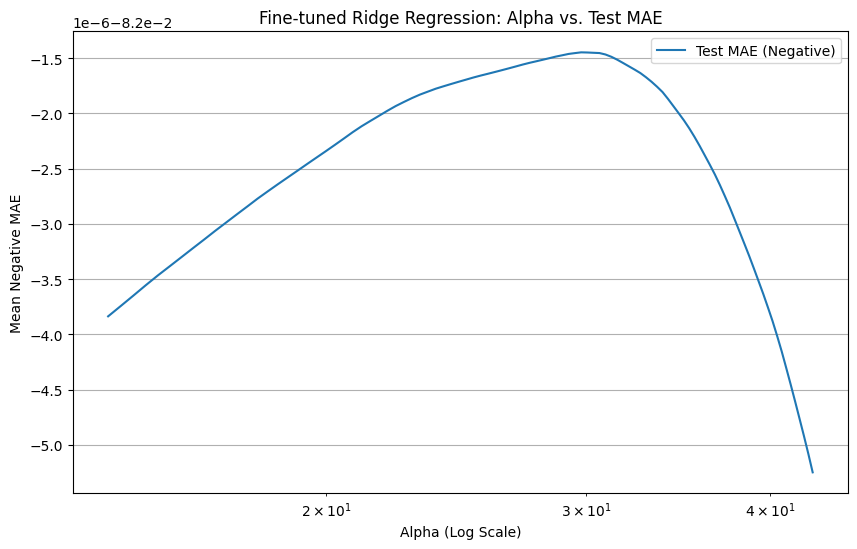

Best alpha for fine-tuned Ridge: 29.7749
Best score (negative MAE) for fine-tuned Ridge: -0.0820


In [ ]:
# Plot train and test scores against alpha
car_price_prediction_ridge_fine_tune_df = pd.DataFrame(car_price_prediction_ridge_fine_tune.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(car_price_prediction_ridge_fine_tune_df['param_alpha'], car_price_prediction_ridge_fine_tune_df['mean_test_score'], label='Test MAE (Negative)')
plt.xscale('log') # Use log scale if the range is still wide, or linear if very narrow
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Negative MAE')
plt.title('Fine-tuned Ridge Regression: Alpha vs. Test MAE')
plt.legend()
plt.grid(True)
plt.show()

# Best alpha value
best_alpha_ridge_fine_tune = car_price_prediction_ridge_fine_tune.best_params_['alpha']
print(f"Best alpha for fine-tuned Ridge: {best_alpha_ridge_fine_tune:.4f}")

# Best score (negative MAE)
best_score_ridge_fine_tune = car_price_prediction_ridge_fine_tune.best_score_
print(f"Best score (negative MAE) for fine-tuned Ridge: {best_score_ridge_fine_tune:.4f}")

In [ ]:
# Set best alpha for Ridge regression
car_price_prediction_ridge_best_alpha = Ridge(alpha=best_alpha_ridge_fine_tune)

# Fit the Ridge model to get the coefficients of the fitted model
car_price_prediction_ridge_best_alpha.fit(X_train_scaled, y_train)

Ridge(alpha=np.float64(29.774920442737958))

In [ ]:
# Show the coefficients for each feature
ridge_coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': car_price_prediction_ridge_best_alpha.coef_})
ridge_coefficients = ridge_coefficients.sort_values(by='Coefficient', ascending=False)
print("Ridge Model Coefficients:")
display(ridge_coefficients)

Ridge Model Coefficients:


,Feature,Coefficient
4,hp_kW,0.098136
71,make_model_Renault Espace,0.036545
65,make_model_Audi A3,0.034820
84,Gearing_Type_Semi-automatic,0.019363
59,has_LED_Headlights,0.017284
...,...,...
66,make_model_Opel Astra,-0.084455
0,km,-0.088932
2,age,-0.100814
70,make_model_Renault Clio,-0.127171


In [ ]:
# Evaluate the Ridge model on the test data
y_pred_ridge = car_price_prediction_ridge_best_alpha.predict(X_test_scaled)

# Calculate evaluation metrics for Ridge model
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Model - Mean Absolute Error (MAE): {mae_ridge:.4f}")
print(f"Ridge Model - Mean Squared Error (MSE): {mse_ridge:.4f}")
print(f"Ridge Model - Root Mean Squared Error (RMSE): {rmse_ridge:.4f}")
print(f"Ridge Model - R-squared (R2): {r2_ridge:.4f}")

Ridge Model - Mean Absolute Error (MAE): 0.0804
Ridge Model - Mean Squared Error (MSE): 0.0116
Ridge Model - Root Mean Squared Error (RMSE): 0.1077
Ridge Model - R-squared (R2): 0.9275


### **3.3 Lasso Regression Implementation**

#### **3.3.1**Define a list of random alpha values

In [ ]:
# List of alphas to tune for Lasso regularisation
alphas_lasso = np.logspace(-4, 2, 100)

#### **3.3.2**Apply Lasso Regularisation and find the best value of alpha from the list

In [ ]:
# Initialise Lasso regression model
lasso = Lasso()
parameters_lasso = {'alpha': alphas_lasso}

car_price_prediction_lasso = GridSearchCV(lasso, parameters_lasso, scoring='neg_mean_absolute_error', cv=5)
car_price_prediction_lasso.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226722e-03, 1.23284674e-03, 1....
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
             scoring='neg_mean_absolute_error')

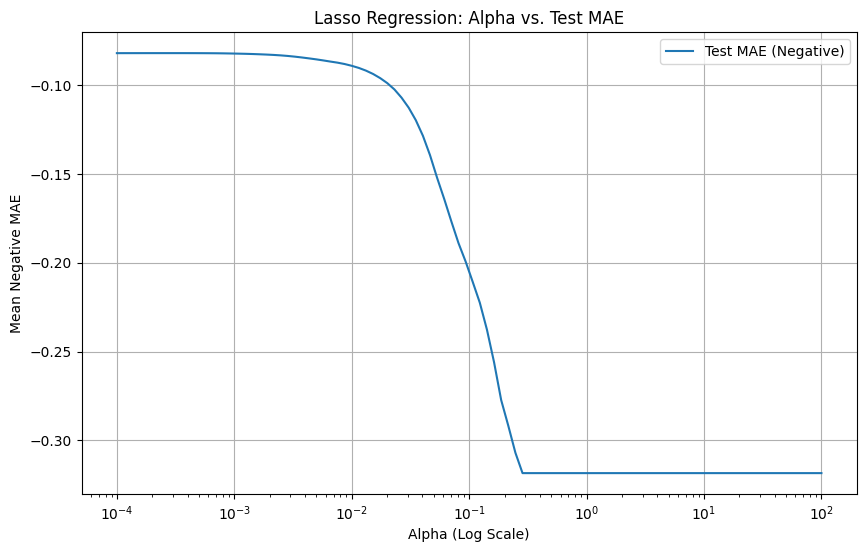

In [ ]:
# Plot train and test scores against alpha
car_price_prediction_lasso_df = pd.DataFrame(car_price_prediction_lasso.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(car_price_prediction_lasso_df['param_alpha'], car_price_prediction_lasso_df['mean_test_score'], label='Test MAE (Negative)')
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Negative MAE')
plt.title('Lasso Regression: Alpha vs. Test MAE')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Best alpha value
best_alpha_lasso = car_price_prediction_lasso.best_params_['alpha']
print(f"Best alpha for Lasso: {best_alpha_lasso:.4f}")

# Best score (negative MAE)
best_score_lasso = car_price_prediction_lasso.best_score_
print(f"Best score (negative MAE) for Lasso: {best_score_lasso:.4f}")

Best alpha for Lasso: 0.0003
Best score (negative MAE) for Lasso: -0.0820


#### **3.3.3**Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# Take a smaller range of alpha to test
alpha_min_lasso = max(0.000001, best_alpha_lasso * 0.5)
alpha_max_lasso = best_alpha_lasso * 1.5
alphas_lasso_fine_tune = np.linspace(alpha_min_lasso, alpha_max_lasso, 100)

In [ ]:
# Applying Lasso regression (fine-tune)
lasso_fine_tune = Lasso()
parameters_lasso_fine_tune = {'alpha': alphas_lasso_fine_tune}

car_price_prediction_lasso_fine_tune = GridSearchCV(lasso_fine_tune, parameters_lasso_fine_tune, scoring='neg_mean_absolute_error', cv=5)
car_price_prediction_lasso_fine_tune.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([0.00015269, 0.00015578, 0.00015886, 0.00016195, 0.00016503,
       0.00016812, 0.0001712 , 0.00017429, 0.00017737, 0.00018046,
       0.00018354, 0.00018662, 0.00018971, 0.00019279, 0.00019588,
       0.00019896, 0.00020205, 0.00020513, 0.00020822, 0.0002113 ,
       0.00021439, 0.00021747, 0.00022056, 0.00022364, 0.00022673,
       0.00022981, 0.0...
       0.00036862, 0.00037171, 0.00037479, 0.00037788, 0.00038096,
       0.00038405, 0.00038713, 0.00039021, 0.0003933 , 0.00039638,
       0.00039947, 0.00040255, 0.00040564, 0.00040872, 0.00041181,
       0.00041489, 0.00041798, 0.00042106, 0.00042415, 0.00042723,
       0.00043032, 0.0004334 , 0.00043649, 0.00043957, 0.00044265,
       0.00044574, 0.00044882, 0.00045191, 0.00045499, 0.00045808])},
             scoring='neg_mean_absolute_error')

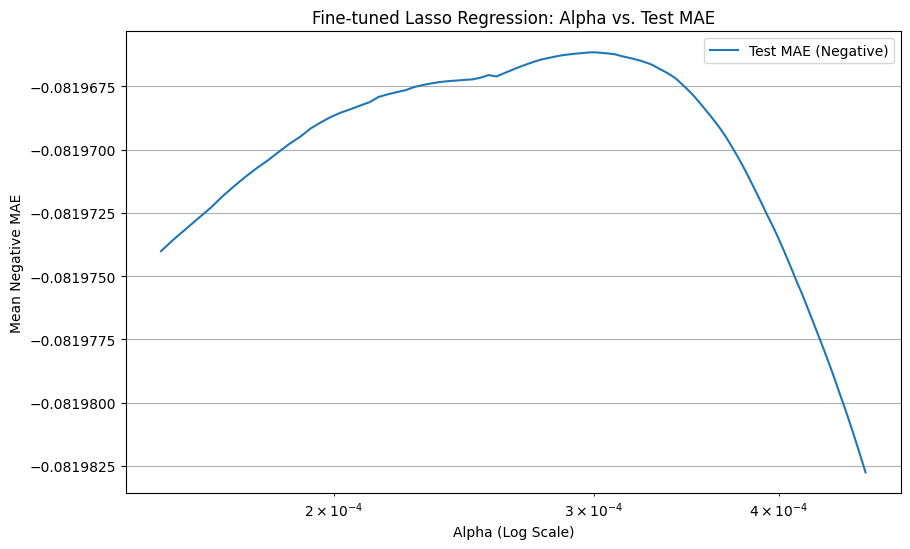

In [ ]:
# Plot train and test scores against alpha (fine-tuned)
car_price_prediction_lasso_fine_tune_df = pd.DataFrame(car_price_prediction_lasso_fine_tune.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(car_price_prediction_lasso_fine_tune_df['param_alpha'], car_price_prediction_lasso_fine_tune_df['mean_test_score'], label='Test MAE (Negative)')
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Negative MAE')
plt.title('Fine-tuned Lasso Regression: Alpha vs. Test MAE')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Best alpha value (fine-tuned)
best_alpha_lasso_fine_tune = car_price_prediction_lasso_fine_tune.best_params_['alpha']
print(f"Best alpha for fine-tuned Lasso: {best_alpha_lasso_fine_tune:.4f}")

# Best score (negative MAE) (fine-tuned)
best_score_lasso_fine_tune = car_price_prediction_lasso_fine_tune.best_score_
print(f"Best score (negative MAE) for fine-tuned Lasso: {best_score_lasso_fine_tune:.4f}")

Best alpha for fine-tuned Lasso: 0.0003
Best score (negative MAE) for fine-tuned Lasso: -0.0820


In [ ]:
# Set best alpha for Lasso regression
car_price_prediction_lasso_best_alpha = Lasso(alpha=best_alpha_lasso_fine_tune)

# Fit the Lasso model on scaled training data
car_price_prediction_lasso_best_alpha.fit(X_train_scaled, y_train)

Lasso(alpha=np.float64(0.0003007584970820788))

In [ ]:
# Check the coefficients for each feature
lasso_coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': car_price_prediction_lasso_best_alpha.coef_})
lasso_coefficients = lasso_coefficients.sort_values(by='Coefficient', ascending=False)
print("Lasso Model Coefficients:")
display(lasso_coefficients)

Lasso Model Coefficients:


,Feature,Coefficient
4,hp_kW,0.099003
71,make_model_Renault Espace,0.036533
65,make_model_Audi A3,0.034232
84,Gearing_Type_Semi-automatic,0.019204
59,has_LED_Headlights,0.017164
...,...,...
66,make_model_Opel Astra,-0.084489
0,km,-0.088463
2,age,-0.101840
70,make_model_Renault Clio,-0.126534


In [ ]:
# Evaluate the Lasso model on the test data
y_pred_lasso = car_price_prediction_lasso_best_alpha.predict(X_test_scaled)

# Calculate evaluation metrics for Lasso model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Model - Mean Absolute Error (MAE): {mae_lasso:.4f}")
print(f"Lasso Model - Mean Squared Error (MSE): {mse_lasso:.4f}")
print(f"Lasso Model - Root Mean Squared Error (RMSE): {rmse_lasso:.4f}")
print(f"Lasso Model - R-squared (R2): {r2_lasso:.4f}")

Lasso Model - Mean Absolute Error (MAE): 0.0803
Lasso Model - Mean Squared Error (MSE): 0.0116
Lasso Model - Root Mean Squared Error (RMSE): 0.1076
Lasso Model - R-squared (R2): 0.9275


### **3.4 Regularisation Comparison & Analysis**

#### **3.4.1**Compare the evaluation metrics for each model.

In [ ]:
# Compare metrics for each model
metrics_data = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [mae, mae_ridge, mae_lasso],
    'MSE': [mse, mse_ridge, mse_lasso],
    'RMSE': [rmse, rmse_ridge, rmse_lasso],
    'R2 Score': [r2, r2_ridge, r2_lasso]
}

metrics_df = pd.DataFrame(metrics_data)

display(metrics_df)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.080369,0.011592,0.107665,0.927480
1,Ridge Regression,0.080369,0.011592,0.107665,0.927480
2,Lasso Regression,0.080345,0.011588,0.107649,0.927501


#### **3.4.2**Compare the coefficients for the three models.

In [ ]:
# Get coefficients for Linear Regression model
linear_coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': car_price_prediction.coef_})
linear_coefficients = linear_coefficients.sort_values(by='Coefficient', ascending=False)

# Combine all coefficients into a single DataFrame for comparison
all_coefficients = linear_coefficients.set_index('Feature')
all_coefficients.columns = ['Linear Regression']
all_coefficients['Ridge Regression'] = ridge_coefficients.set_index('Feature')['Coefficient']
all_coefficients['Lasso Regression'] = lasso_coefficients.set_index('Feature')['Coefficient']

display(all_coefficients)

,Linear Regression,Ridge Regression,Lasso Regression
Feature,,,
hp_kW,0.098763,0.098136,0.099003
make_model_Renault Espace,0.035807,0.036545,0.036533
make_model_Audi A3,0.034091,0.034820,0.034232
Gearing_Type_Semi-automatic,0.019354,0.019363,0.019204
has_LED_Headlights,0.017247,0.017284,0.017164
...,...,...,...
make_model_Opel Astra,-0.086540,-0.084455,-0.084489
km,-0.088984,-0.088932,-0.088463
age,-0.101140,-0.100814,-0.101840


Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [ ]:
# Identify features dropped by Lasso (coefficients equal to zero)
lasso_dropped_features = lasso_coefficients[lasso_coefficients['Coefficient'] == 0.0]
if not lasso_dropped_features.empty:
    print("\nFeatures eliminated by Lasso Regression (coefficients are zero):")
    display(lasso_dropped_features)
else:
    print("\nLasso Regression did not eliminate any features (no coefficients are exactly zero).")


Features eliminated by Lasso Regression (coefficients are zero):


,Feature,Coefficient
44,has_Touch_screen,-0.0
28,has_Electrically_adjustable_seats,0.0
33,has_Radio,-0.0
34,has_Sound_system,0.0
63,has_Traffic_sign_recognition,-0.0
79,Fuel_Others,0.0
74,body_type_Station wagon,0.0


## **4 Conclusion & Key Takeaways**

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained**